# 4. Model Evaluation

## Summary
This notebook evaluates the performance of the trained DronePrint LSTM model. 

Steps involved:
1. Load the Test dataset and the saved Best Model from Notebook 03.
2. Generate standard evaluation metrics: Classification Report and Confusion Matrix.
3. Implement the DronePrint paper's **Inference Strategy** (averaging predictions over consecutive time windows).
4. Provide a testing pipeline for a completely unseen, raw `.wav` file to verify real-world robustness and check for data leakage.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# seed
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
# 1. Load Data
FEATURE_DIR = "./features"
X_test = np.load(os.path.join(FEATURE_DIR, 'X_features.npy')) # Wait, we need to load the split data. 
# Since train_test_split was random in Notebook 03, we need to re-create the split or evaluate on the whole set.
# To be mathematically precise to your previous split, let's re-run the split with the SAME random_state=42.

from sklearn.model_selection import train_test_split

X_all = np.load(os.path.join(FEATURE_DIR, 'X_features.npy'))
y_all = np.load(os.path.join(FEATURE_DIR, 'y_labels.npy'))
label_classes = np.load(os.path.join(FEATURE_DIR, 'label_classes.npy'), allow_pickle=True)

# Recreate the exact same split from Notebook 03 (using the exact same random_state)
_, X_temp, _, y_temp = train_test_split(X_all, y_all, test_size=0.20, random_state=42, stratify=y_all)
_, X_test, _, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Loaded X_test shape: {X_test.shape}")
print(f"Loaded y_test shape: {y_test.shape}")

# 2. Load the Model
MODEL_DIR = "./models"
model_path = os.path.join(MODEL_DIR, "droneprint_best_model.keras")
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully.")

Loaded X_test shape: (3366, 10, 13)
Loaded y_test shape: (3366,)
Model loaded successfully.


106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- Classification Report ---
              precision    recall  f1-score   support

       drone       1.00      1.00      1.00      1184
   non_drone       1.00      1.00      1.00      2182

    accuracy                           1.00      3366
   macro avg       1.00      1.00      1.00      3366
weighted avg       1.00      1.00      1.00      3366



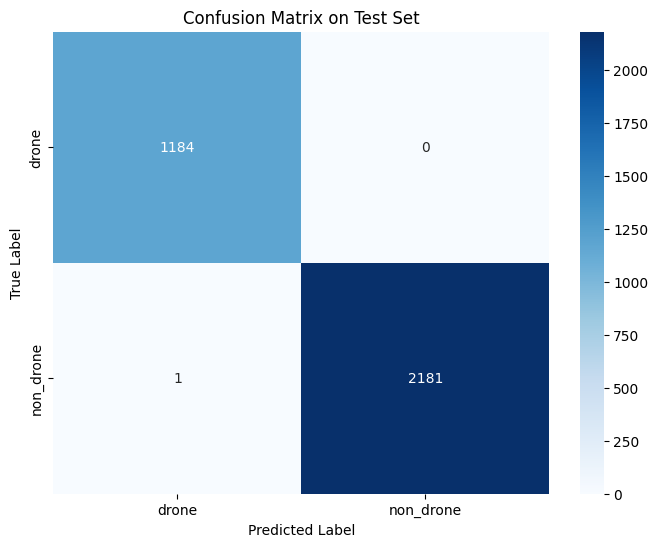

In [ ]:
# Predict probabilities for the test set
y_pred_probs = model.predict(X_test)

# Convert probabilities to class labels (0 or 1)
y_pred = np.argmax(y_pred_probs, axis=1)

# 1. Classification Report (Precision, Recall, F1)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=label_classes))

# 2. matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_classes, 
            yticklabels=label_classes)
plt.title('Confusion Matrix on Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
def extract_and_normalize_mfcc(file_path, n_mfcc=13, n_fft=2048, hop_length=512):
    """Reused from Notebook 02 to process new incoming audio."""
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    l2_norm = np.linalg.norm(mfcc, axis=0, keepdims=True)
    mfcc_normalized = mfcc / (l2_norm + 1e-10)
    return mfcc_normalized.T

def create_sequences(features, time_steps=10):
    """Reused from Notebook 02."""
    sequences = []
    if len(features) < time_steps:
        pad_width = time_steps - len(features)
        features = np.pad(features, ((0, pad_width), (0, 0)), mode='constant')
        return [features]
    
    for i in range(0, len(features) - time_steps + 1, time_steps):
        sequences.append(features[i : i + time_steps])
    return np.array(sequences)

def predict_unseen_audio(file_path, model, label_classes):
    """
    Implements the paper's inference strategy:
    Extracts features, runs them through the model, and averages the 
    probabilities across the time windows to make a final decision.
    """
    print(f"Analyzing: {file_path}")
    
    # 1. processar áudio
    features = extract_and_normalize_mfcc(file_path)
    if features is None:
        return "Error reading file"
        
    sequences = create_sequences(features)
    
    # 2. predict on all sequences
    predictions = model.predict(sequences, verbose=0)
    
    # 3. aplicar a DronePrint Inference Strategy (Average Probabilities)
    avg_probabilities = np.mean(predictions, axis=0)
    
    # 4. classificação final
    predicted_class_idx = np.argmax(avg_probabilities)
    predicted_class_label = label_classes[predicted_class_idx]
    confidence = avg_probabilities[predicted_class_idx] * 100
    
    print(f"Final Verdict: {predicted_class_label} (Confidence: {confidence:.2f}%)")
    
    # Plot
    plt.figure(figsize=(6, 4))
    sns.barplot(x=label_classes, y=avg_probabilities * 100)
    plt.title("Average Prediction Probabilities")
    plt.ylabel("Probability (%)")
    plt.ylim(0, 100)
    plt.show()
    
    return predicted_class_label

In [5]:
def extract_and_normalize_mfcc(file_path, n_mfcc=13, n_fft=2048, hop_length=512):
    """Reused from Notebook 02 to process new incoming audio."""
    y, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    l2_norm = np.linalg.norm(mfcc, axis=0, keepdims=True)
    mfcc_normalized = mfcc / (l2_norm + 1e-10)
    return mfcc_normalized.T

def create_sequences(features, time_steps=10):
    """Reused from Notebook 02."""
    sequences = []
    if len(features) < time_steps:
        pad_width = time_steps - len(features)
        features = np.pad(features, ((0, pad_width), (0, 0)), mode='constant')
        return [features]
    
    for i in range(0, len(features) - time_steps + 1, time_steps):
        sequences.append(features[i : i + time_steps])
    return np.array(sequences)

def predict_unseen_audio(file_path, model, label_classes):
    """
    Implements the paper's inference strategy:
    Extracts features, runs them through the model, and averages the 
    probabilities across the time windows to make a final decision.
    """
    print(f"Analyzing: {file_path}")
    
    # 1. Process Audio
    features = extract_and_normalize_mfcc(file_path)
    if features is None:
        return "Error reading file"
        
    sequences = create_sequences(features)
    
    # 2. Predict on all sequences
    predictions = model.predict(sequences, verbose=0)
    
    # 3. Apply DronePrint Inference Strategy (Average Probabilities)
    avg_probabilities = np.mean(predictions, axis=0)
    
    # 4. Final Classification
    predicted_class_idx = np.argmax(avg_probabilities)
    predicted_class_label = label_classes[predicted_class_idx]
    confidence = avg_probabilities[predicted_class_idx] * 100
    
    print(f"Final Verdict: {predicted_class_label} (Confidence: {confidence:.2f}%)")
    
    # Plotting the confidence distribution
    plt.figure(figsize=(6, 4))
    sns.barplot(x=label_classes, y=avg_probabilities * 100)
    plt.title("Average Prediction Probabilities")
    plt.ylabel("Probability (%)")
    plt.ylim(0, 100)
    plt.show()
    
    return predicted_class_label

In [ ]:
# =========================================================================
# THE ULTIMATE TEST
# Find a piece of audio online (e.g., a YouTube drone review) that was 
# NEVER used in your Notebook 01 dataset. Download it as a .wav file.
# Replace the path below and run it. 
# =========================================================================

# Example: (Update this path to a real, newly downloaded test file on your PC)
UNSEEN_TEST_FILE = "./data/unseen_test_drone_audio.wav" 

if os.path.exists(UNSEEN_TEST_FILE):
    predict_unseen_audio(UNSEEN_TEST_FILE, model, label_classes)
else:
    print(f"Please place a new, unseen audio file at {UNSEEN_TEST_FILE} to test for data leakage.")